## K-Nearest Neighbors Example: Predicting Player Position Using Height and Weight ##

Most NFL players very clearly fit their position's prototypical bodytype. A few are physical anomalies. We seek to develop a method to identify these players. 

In [8]:
import numpy as np
import rice_ml
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

We will be using historical NFL data from players that have played in the last 10 years. We want to classify whether a player is a running back (RB), wide receiver (WR), or tight end (TE) using their height and weight. We will use a K-Nearest Neighbors model as defined in the rice_ml package to do so. 

In [37]:
# Load in NFL receiving stats dataset
csv_path = Path("..") / "data" / "NFL_players.csv"
data = pd.read_csv(csv_path)
# Display the first 5 rows of the dataset
data.head(5)

,Unnamed: 0,gsis_id,display_name,common_first_name,first_name,last_name,short_name,football_name,suffix,esb_id,...,status,ngs_status,ngs_status_short_description,years_of_experience,pff_position,pff_status,draft_year,draft_round,draft_pick,draft_team
0,1,00-0028830,Isaako Aaitui,Isaako,Isaako,Aaitui,NaN,NaN,NaN,AAI622937,...,DEV,NaN,NaN,2,DI,NaN,NaN,NaN,NaN,NaN
1,2,00-0038389,Israel Abanikanda,Israel,Israel,Abanikanda,I.Abanikanda,Israel,NaN,ABA159567,...,ACT,RES,Reserve/Future,3,HB,A,2023.0,5.0,143.0,NYJ
2,3,00-0024644,Jon Abbate,Jon,Jon,Abbate,NaN,NaN,NaN,ABB051371,...,RES,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ABB498348,Vince Abbott,Vince,Vincent,Abbott,NaN,NaN,NaN,ABB498348,...,ACT,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,5,00-0031021,Jared Abbrederis,Jared,Jared,Abbrederis,J.Abbrederis,Jared,NaN,ABB650964,...,CUT,CUT,NaN,4,WR,NaN,2014.0,5.0,176.0,GB


To clean our data, we first filter down to players who were active in the last 10 years. Then, we limit our dataset to the positions in question (RB, WR, TE). After that, we cut our dataset down to only our relavent columns: name, position, height, and weight. Finally, we use the in-built rice_ml Standard Scaler to standardize our feature vectors. We are now ready to split the data and imeplement the model. 

In [38]:
# Filter data to players active after or equal to 2015
data = data[data["last_season"] >= 2015]
# Limit data to RB, WR, TE positions
data = data[data["position"].isin(["RB", "WR", "TE"])]
# Limit data to relevant columns
data = data[["display_name", "position", "height", "weight"]]
# Standardize height and weight columns
scaler = rice_ml.StandardScaler()
features_to_scale = ["height", "weight"]
data[features_to_scale] = scaler.fit_transform(data[features_to_scale].values)
# Display the first 10 rows of the filtered dataset
data.head(10)

,display_name,position,height,weight
1,Israel Abanikanda,RB,-1.082166,-0.004822
4,Jared Abbrederis,WR,-0.050072,-0.841659
7,Ameer Abdullah,RB,-1.426197,-0.522864
34,De'Von Achane,RB,-1.426197,-1.001056
61,Davante Adams,WR,-0.050072,-0.044672
74,Jerell Adams,TE,1.326054,1.509453
76,Josh Adams,RB,0.293960,0.353822
94,Rodney Adams,WR,-0.050072,-1.080755
114,Bralon Addison,WR,-1.426197,-0.761960
116,Jordan Addison,WR,-0.738134,-1.638646


Before initializing the model, we split our data into training sets (80%) and testing sets (20%). There is no true "training" step in the KNN implementation. We use this split to predict the testing data using the training data as neighbors. We are choosing to do this to provide a proof of concept for the methodology we discussed. 

In [39]:
# Split data into train and test sets
train_data = data.sample(frac=0.8, random_state=42)
test_data = data.drop(train_data.index)

# Separate features and labels for training and testing sets
X_train = train_data[["height", "weight"]].values
y_train = train_data["position"].values
X_test = test_data[["height", "weight"]].values
y_test = test_data["position"].values


To initialize our KNN model, we simply call the KNN class from the rice_ml package. The only initialization arguement is k, the number of neighbors we are looking for to make our classification. We will set k = 15 since it tends to yield the best results after trying several k values. To use the model, we can either predict a single point, or an entire array. Since we have a large dataset, we will predict the whole array at once. There are three arguements for the prediction methods: the training features, training labels, and testing features. The model takes the euclidean distance between testing features and training features for all points, averages the distances, and identifies the k closest points to our test points. Then, based on which label occurs most frequently among those points, the model assigns our target points a label. 

In [40]:
# Initialize KNN Model
knn = rice_ml.KNearestNeighbors(k=15)

# Predict labels for test set
y_pred = knn.predict(X_train, y_train, X_test)

# Print a 4x4 confusion matrix
cm = pd.crosstab(
        pd.Series(y_test, name='Actual'), 
        pd.Series(y_pred, name='Predicted'), 
        margins=True)
    
print("--- Confusion Matrix ---")
print(cm)

# Print the accuracy,  of the model
accuracy = rice_ml.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


--- Confusion Matrix ---
Predicted   RB   TE   WR  All
Actual                       
RB         105    5   28  138
TE           1  113    5  119
WR          17    0  215  232
All        123  118  248  489
Accuracy: 0.89


The accuracy of the model is very high at 89%. As we can see from the confusion matrix, All three positions are very accurately predicted, indicating that height and weight generally define a players position very well. We can use a scatterplot to see the clusters and identify where the errors are coming from. 

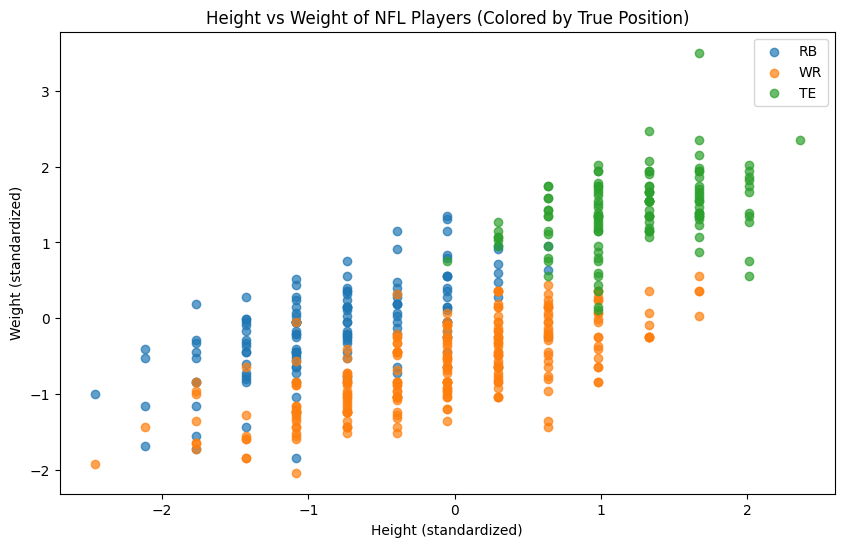

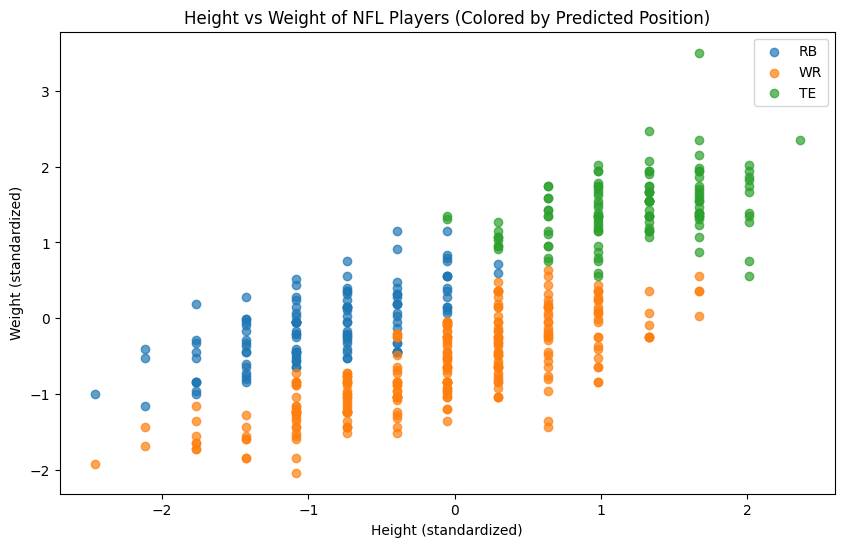

In [43]:
# Plot scatter plot of height vs weight, colored by true position
pos_colors = {
    "RB": "#1f77b4",  # Blue
    "WR": "#ff7f0e",  # Orange
    "TE": "#2ca02c"   # Green
}
positions = ["RB", "WR", "TE"]

# Plot 1: True Position
plt.figure(figsize=(10, 6))
for position in positions:
    subset = test_data[test_data["position"] == position]
    plt.scatter(
        subset["height"], 
        subset["weight"], 
        label=position, 
        color=pos_colors[position], 
        alpha=0.7
    )
plt.xlabel("Height (standardized)")
plt.ylabel("Weight (standardized)")
plt.title("Height vs Weight of NFL Players (Colored by True Position)")
plt.legend()
plt.show()

# --- Plot 2: Predicted Position ---
plt.figure(figsize=(10, 6))
for position in positions:
    subset = test_data[y_pred == position]
    plt.scatter(
        subset["height"], 
        subset["weight"], 
        label=position, 
        color=pos_colors[position], 
        alpha=0.7
    )
plt.xlabel("Height (standardized)")
plt.ylabel("Weight (standardized)")
plt.title("Height vs Weight of NFL Players (Colored by Predicted Position)")
plt.legend()
plt.show()

We can see three definitive clusters in both the predicted and true position plots. The difference between RBs and WRs seems to follow an approximate line balancing height and weight up until we reach TE height. Effectively, there is a weight threshold at a given height where players generally go from being RBs to WRs. Typically, RBs are heavier than WRs. The misclassifications between these two groups occur when a WR is heavier than expected or a RB is lighter than expected up to an average height. Typically, these lighter RBs are used more in the pass game, playing roles very similar to a WR (e.g. Darren Sproles, Duece Vaughn). Once we hit the league average height, the dichotomy shifts to TEs and WRs. Heavier tall players are typically TEs, while lighter tall players are WRs. This makes sense, considering TEs have more inline blocking responsibilities in the run game, requiring more muscle mass. The misclassifications between WRs and TEs occur when we have a lighter than typical TE or a heavier than typical WR at a given height. In game situations, these lighter TEs are likely to play a role more similar to a WR than a true TE (e.g. Kyle Pitts, Jonnu Smith).

Overall, we can see that height and weight already very clearly separate skill position groups in the NFL. There are some outlier players that are classified as one position but fit more closely in another role. By utilizing KNN clustering, we can identify these "outlier" players and potentially evaluate them in their more physically natural positions. 